# DATA CLEANING

In [1]:
import pandas as pd 

In [5]:
df = pd.read_csv(r"C:/Users/santh/OneDrive/Desktop/PROJECTS/HR Analytics/hr dataset.csv")

In [7]:
df.head()

,Age,Attrition,Business_Travel,Daily_Rate,Department,Distance_From_Home,Education,Education_Field,Employee_Count,Employee_Number,...,Training_Times_LastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,age_group,Experience_Group,Attrition_flag,Month
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,1,6,4,0,5,36-45,5+,1,Jan-00
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,3,10,7,1,7,45+,5+,0,Jan-00
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,36-45,0-2,1,Jan-00
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,25-35,5+,0,Jan-00
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,25-35,03-May,0,Jan-00


In [9]:
df.shape

(1470, 39)

In [10]:
df.info

<bound method DataFrame.info of       Age Attrition    Business_Travel  Daily_Rate              Department  \
0      41       Yes      Travel_Rarely        1102                   Sales   
1      49        No  Travel_Frequently         279  Research & Development   
2      37       Yes      Travel_Rarely        1373  Research & Development   
3      33        No  Travel_Frequently        1392  Research & Development   
4      27        No      Travel_Rarely         591  Research & Development   
...   ...       ...                ...         ...                     ...   
1465   36        No  Travel_Frequently         884  Research & Development   
1466   39        No      Travel_Rarely         613  Research & Development   
1467   27        No      Travel_Rarely         155  Research & Development   
1468   49        No  Travel_Frequently        1023                   Sales   
1469   34        No      Travel_Rarely         628  Research & Development   

      Distance_From_Home  Educa

In [11]:
df.isnull().sum()

Age                          0
Attrition                    0
Business_Travel              0
Daily_Rate                   0
Department                   0
Distance_From_Home           0
Education                    0
Education_Field              0
Employee_Count               0
Employee_Number              0
Environment_Satisfaction     0
Gender                       0
Hourly_Rate                  0
Job_Involvement              0
Job_Level                    0
Job_Role                     0
Job_Satisfaction             0
Marital_Status               0
Monthly_Income               0
Monthly_Rate                 0
NumCompanies_Worked          0
Over18                       0
Over_Time                    0
Percent_Salary_Hike          0
Performance_Rating           0
Relationship_Satisfaction    0
Standard_Hours               0
Stock_Option_Level           0
Total_Working_Years          0
Training_Times_LastYear      0
WorkLifeBalance              0
YearsAtCompany               0
YearsInC

In [12]:
df.duplicated().sum()

np.int64(0)

# WORKFORCE OVERVIEW

In [13]:
# KPI 1 — Total Employees

len(df)

1470

In [14]:
#KPI 2 — Average Age
df['Age'].mean()

np.float64(36.923809523809524)

In [15]:
#KPI 3 — Average Salary
df['Monthly_Income'].mean()

np.float64(6502.931292517007)

In [16]:
#KPI 4 — Average Experience
df['Total_Working_Years'].mean()

np.float64(11.279591836734694)

In [17]:
# KPI 5 - Attrition Rate ⭐

attrition_rate = (
    df['Attrition']
    .value_counts(normalize=True)
    * 100
)

attrition_rate

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

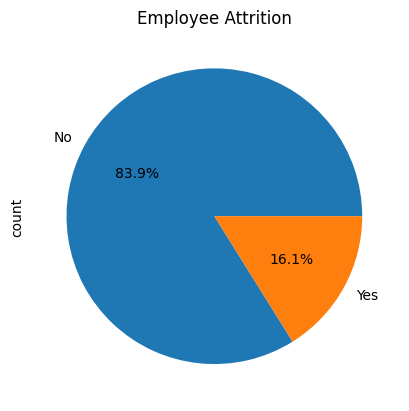

In [18]:
import matplotlib.pyplot as plt

df['Attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Employee Attrition")
plt.show()

# ATTRITION ANALYSIS 

<Axes: xlabel='Over_Time', ylabel='count'>

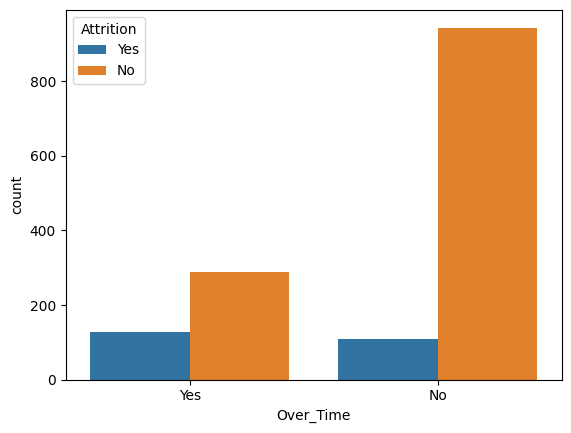

In [19]:
# Question 1 --> Does Overtime Cause Attrition?

pd.crosstab(
    df['Over_Time'],
    df['Attrition']
)

import seaborn as sns

sns.countplot(
    x='Over_Time',
    hue='Attrition',
    data=df
)

<Axes: xlabel='Attrition', ylabel='Monthly_Income'>

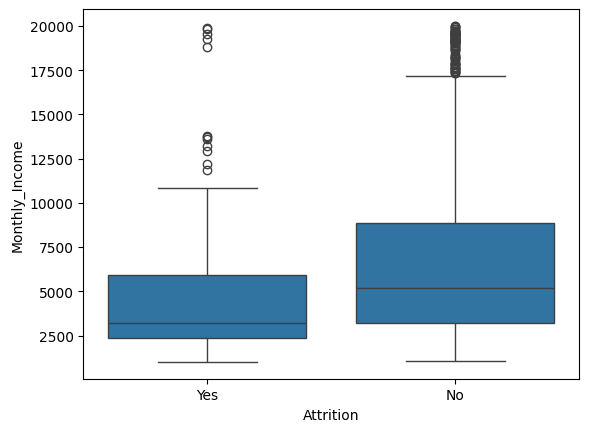

In [20]:
# Question 2 --> Does Salary Affect Attrition?

sns.boxplot(
    x='Attrition',
    y='Monthly_Income',
    data=df
)

<Axes: xlabel='Job_Satisfaction', ylabel='count'>

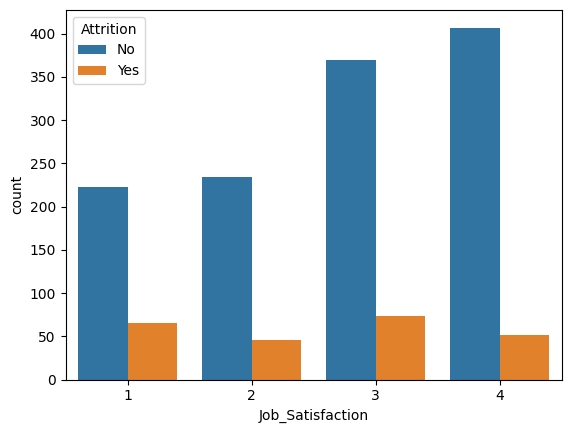

In [21]:
# Question 3 --> Does Job Satisfaction Affect Attrition?

sns.countplot(
    x='Job_Satisfaction',
    hue='Attrition',
    data=df
)

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

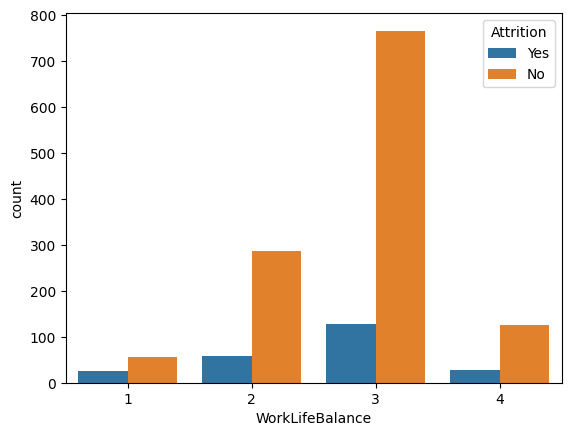

In [22]:
# Question 4 -- > Does Work-Life Balance Affect Attrition?

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)

# DEMOGRAPHIC ANALYSIS

In [23]:
# Attrition by Gender

pd.crosstab(
    df['Gender'],
    df['Attrition']
)

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


In [24]:
# Attrition by Age Group
pd.crosstab(
    df['age_group'],
    df['Attrition']
)

Attrition,No,Yes
age_group,,
25-35,510,122
36-45,425,43
45+,239,34
<25,59,38


# DEPARTMENT ANALYSIS

<Axes: xlabel='Department', ylabel='count'>

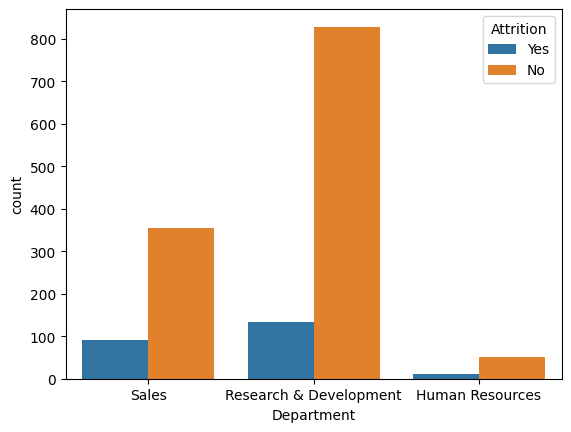

In [27]:
# Attrition by Department
pd.crosstab(
    df['Department'],
    df['Attrition']
)

sns.countplot(
    x='Department',
    hue='Attrition',
    data=df
)

In [28]:
# Attrition by Job Role
pd.crosstab(
    df['Job_Role'],
    df['Attrition']
)

Attrition,No,Yes
Job_Role,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


# EXPERIENCE ANALYSIS

In [30]:
# Attrition by Experience Group
pd.crosstab(
    df['Experience_Group'],
    df['Attrition']
)

Attrition,No,Yes
Experience_Group,,
0-2,140,75
03-May,474,87
5+,619,75


<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

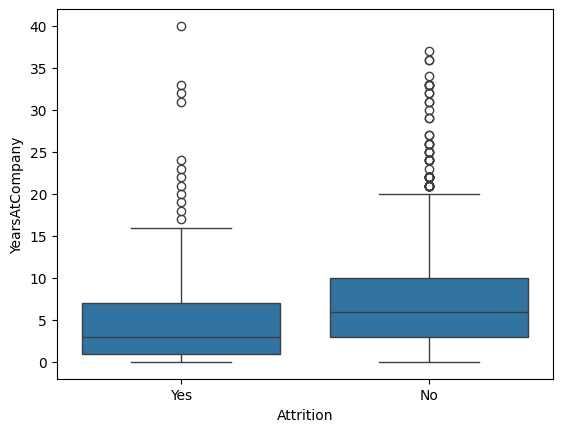

In [31]:
# Attrition by Years At Company
sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)

# CORRELATION ANALYSIS

<Axes: >

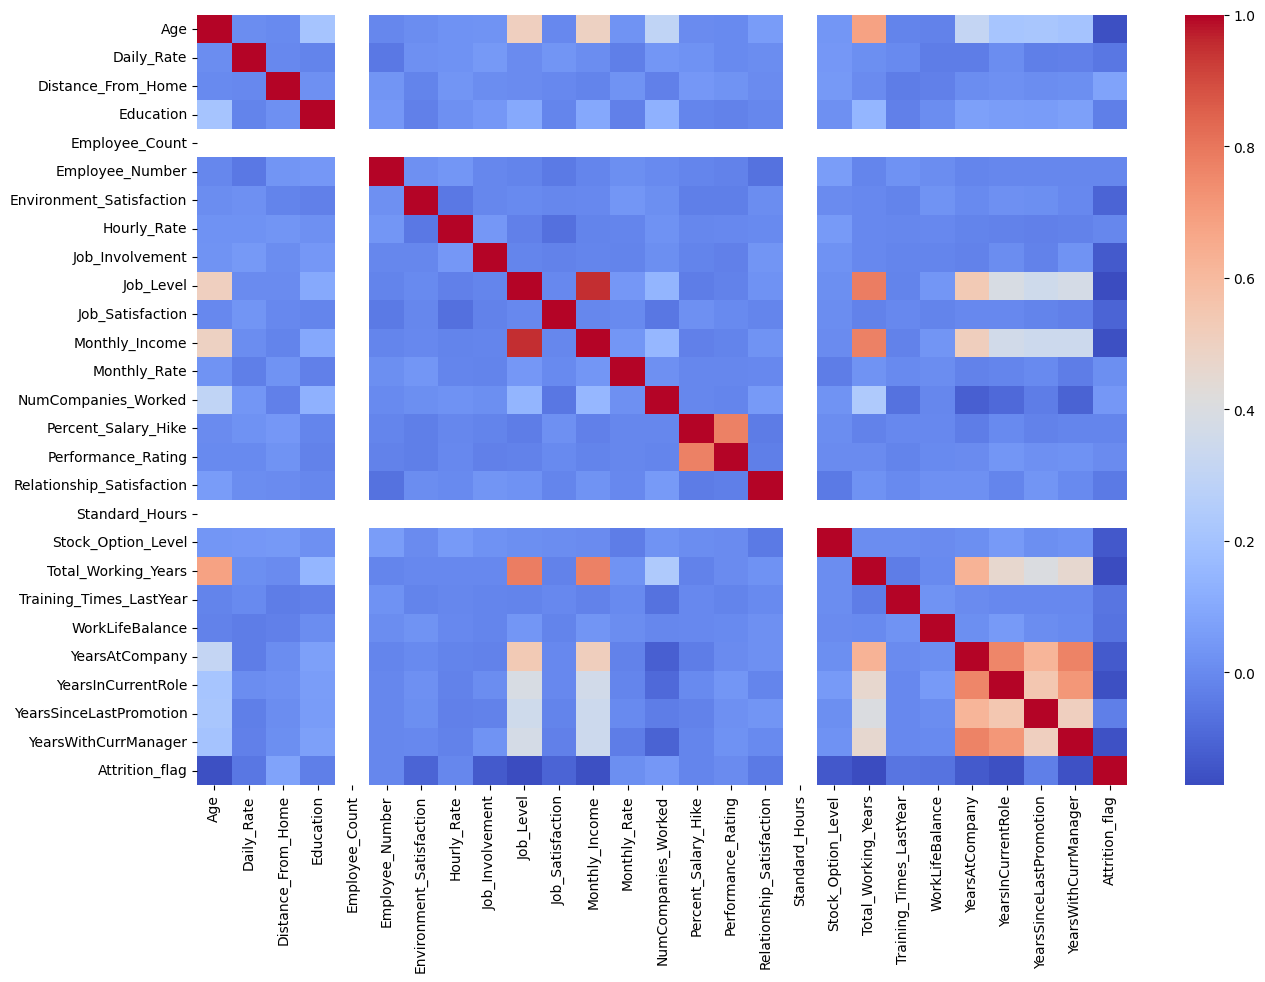

In [32]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)